In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !git clone https://github.com/VSmague/Dynamical-Variational-Autoencoders.git

In [3]:
import os
# os.chdir("Dynamical-Variational-Autoencoders")

In [13]:
!git checkout jlnew

Switched to branch 'jlnew'
Your branch is up to date with 'origin/jlnew'.


In [3]:
# import sys
# sys.path.append('.')
# print("Current directory added to sys.path.")

# Notebook.ipynb content

# Imports

In [4]:
pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 80.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 59.1 MB/s  0:00:00m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 75.2 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [librosa]5/16 [librosa]earn]
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 49.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [6]:

import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob

from model.VRNN import VRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [8]:
model = VRNN().to(device)

On repasse à la branche main pour récupérer les données du dataset.

In [7]:
!git checkout main

M	dataset/__pycache__/audio_dataset.cpython-313.pyc
M	experiments/.ipynb_checkpoints/VRNN_project_notebook_colab-checkpoint.ipynb
M	experiments/VRNN_project_notebook_colab.ipynb
M	experiments/__pycache__/train.cpython-313.pyc
M	experiments/checkpoints/best.pt
M	experiments/checkpoints/history.json
M	experiments/checkpoints/last.pt
M	experiments/train.py
M	model/VRNN.py
M	model/__pycache__/VRNN.cpython-313.pyc
Already on 'main'
Your branch is up to date with 'origin/main'.


In [9]:
#pour colab 
# data_dirs = [
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
#     "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
# ]


#pour sspcloud: 
data_dirs = [
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
"/home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
]

# Initialize AudioDataset for each part and concatenate them
full_dataset = torch.utils.data.ConcatDataset([
    AudioDataset(data_dir) for data_dir in data_dirs
])


all_mels = []
for i in range(len(full_dataset)):
    all_mels.append(full_dataset[i])

all_mels_tensor = torch.cat(all_mels, dim=0)

mean_full = all_mels_tensor.mean()
std_full = all_mels_tensor.std()
print("les données sont déja normalisées attention: ", mean_full,std_full)

les données sont déja normalisées attention:  tensor(0.1526) tensor(0.9705)


In [29]:
N = len(full_dataset)
train_len = int(0.8 * N)
val_len = int(0.1 * N)
test_len = N - train_len - val_len

print(f"Dataset split: Train {train_len}, Validation {val_len}, Test {test_len} samples.")

g = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=g
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)



Dataset split: Train 2337, Validation 292, Test 293 samples.


Type du batch: <class 'torch.Tensor'>
Shape du batch: torch.Size([200, 32, 80])
Shape séquence 0 : torch.Size([200, 80])
tensor([[ 2.0606,  1.4173, -0.2656,  ..., -0.6549, -0.7105, -0.6842],
        [ 1.5566,  1.0054, -0.4522,  ..., -0.6139, -0.8119, -0.5935],
        [ 0.9946,  0.9577, -0.0869,  ...,  0.0235, -0.1195, -0.1012],
        ...,
        [-0.1592,  0.3509,  0.1420,  ..., -0.0039,  0.1501,  0.2234],
        [ 0.1910,  0.0744, -0.3798,  ...,  0.0915,  0.2401,  0.3728],
        [ 0.4840, -0.5122, -0.0201,  ...,  0.1592,  0.3172,  0.5473]])


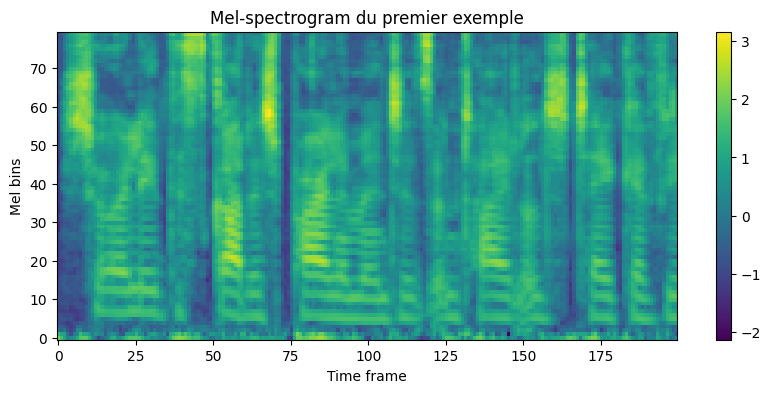

In [30]:
# Récupère le premier batch
batch = next(iter(train_loader))
print("Type du batch:", type(batch))
print("Shape du batch:", batch.shape)

x0 = batch[:, 0, :]   # shape = (seq_len, mel_dim)
print("Shape séquence 0 :", x0.shape)
print(x0)

plt.figure(figsize=(10,4))
plt.imshow(x0.T, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Mel-spectrogram du premier exemple")
plt.xlabel("Time frame")
plt.ylabel("Mel bins")
plt.show()

In [31]:
import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob
from tqdm import tqdm # Import tqdm

from model.VRNN import VRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate



import os
import json
import torch


def save_checkpoint(state, checkpoint_dir, name="last.pt"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, name)
    torch.save(state, path)


def load_checkpoint(model, optimizer, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Checkpoint loaded from: {checkpoint_path}")
    return start_epoch, history


def evaluate(model, dataloader, device):
    model.eval()
    total_recon, total_kld = 0, 0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)              # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)        # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            _,recon, kld = model(batch)
            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

    return total_recon / n_batches, total_kld / n_batches



def train_model(
    model,
    train_loader,
    val_loader,
    checkpoint_dir="checkpoints",
    resume=False,
    epochs=50,
    batch_size=32,
    lr=1e-4,
    kl_anneal_epochs=10,
    patience=7,
    device="cuda"
):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Tracking
    history = {
        "train": [],
        "val": [],
        "beta": [],
        "train_recon": [],
        "train_kld": [],
        "val_recon": [],
        "val_kld": []
    }

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume training
    last_ckpt = os.path.join(checkpoint_dir, "last.pt")
    if resume and os.path.exists(last_ckpt):
        start_epoch, history = load_checkpoint(model, optimizer, last_ckpt, device)
        print(f"Resuming from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_recon, total_kld = 0, 0
        n_batches = 0

        beta = min(1.0, epoch / kl_anneal_epochs)

        # Wrap train_loader with tqdm for a progress bar
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"): # Added tqdm here
            batch = batch.to(device)             # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)       # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            optimizer.zero_grad()
            _, recon, kld = model(batch)

            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)
            loss = recon + beta * kld

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

        train_recon = total_recon / n_batches
        train_kld = total_kld / n_batches
        train_loss = train_recon + beta * train_kld

        # Validation
        val_recon, val_kld = evaluate(model, val_loader, device=device)
        val_loss = val_recon + beta * val_kld

        print(f"[{epoch+1}/{epochs}] "
              f"Train: {train_loss:.3f} | Val: {val_loss:.3f} | β={beta:.3f}")

        # Update history
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["beta"].append(beta)
        history["train_recon"].append(train_recon)
        history["train_kld"].append(train_kld)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)

        # Save last checkpoint
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, checkpoint_dir, "last.pt")

        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            save_checkpoint({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history
            }, checkpoint_dir, "best.pt")
            patience_counter = 0
            print(" → Saved BEST model")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    # Save history as JSON
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=4)

    print("\nTraining complete.")
    return history



Interpretation: from epoch 10 to 40, the models does not exploit the latent vector z and only relies on the RNN part: this results in a posterior q(z I x) that remains identical to the prior p(z) and a null KL. However, after epoch 40, the model starts using the latent variable z: this results in a decreasing loss but an increase in the KL as q(z I x) changes.

We need to increase the number of epochs and the rate at which parameter beta increases to avoid this phenomenon.

In [ ]:
model = VRNN().to(device)

Epoch 1/150 Training: 100%|██████████| 74/74 [00:17<00:00,  4.28it/s]


[1/150] Train: 10.892 | Val: -14.759 | β=0.000
 → Saved BEST model


Epoch 2/150 Training: 100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


[2/150] Train: -20.499 | Val: -23.464 | β=0.033
 → Saved BEST model


Epoch 3/150 Training: 100%|██████████| 74/74 [00:18<00:00,  4.01it/s]


...

[107/150] Train: -60.877 | Val: -61.477 | β=1.000


Epoch 108/150 Training: 100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


[108/150] Train: -61.292 | Val: -61.637 | β=1.000


Epoch 109/150 Training: 100%|██████████| 74/74 [00:17<00:00,  4.16it/s]


[109/150] Train: -61.340 | Val: -61.252 | β=1.000
Early stopping triggered.

Training complete.


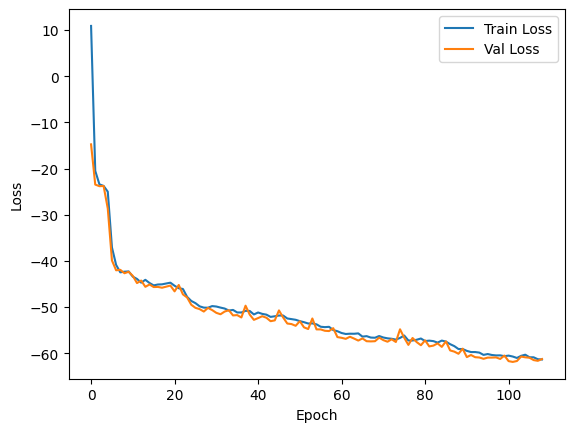

In [19]:


history = train_model(model=model, train_loader=train_loader, val_loader=val_loader,epochs=150,batch_size=32,lr=5e-4,kl_anneal_epochs=30, patience=7,device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Contenu du JSON :
{'train': [10.89225024669557, -20.499482109417787, -23.418933364936898, -23.756448203164176, -25.005390781540054, -37.081258061769844, -40.86402942940995, -42.47390507427422, -42.33259178024154, -42.27591595585282, -43.41435296041472, -43.89854214792853, -44.707465586791166, -44.09314690022855, -44.78337168908334, -45.3000069824425, -45.10944419723373, -45.07034880191356, -44.88898469306327, -44.71645907238797, -45.3782008918556, -45.91560729065456, -46.07665130726926, -47.784344030715324, -48.667805047937335, -49.145079804970344, -49.8352728336781, -50.11533549862939, -50.135713700131255, -49.78247368829744, -49.87744918385068, -50.109294060114266, -50.314204667065596, -50.747865535117484, -50.61441764316044, -51.16140961647034, -51.169784842310726, -50.81077045363349, -50.83906944378002, -51.59363751153688, -51.1681067363636, -51.470550073159714, -51.63855577159572, -52.1233355161306, -51.987842817564264, -51.82798774822338, -51.82853125881505, -52.46730193576297, -

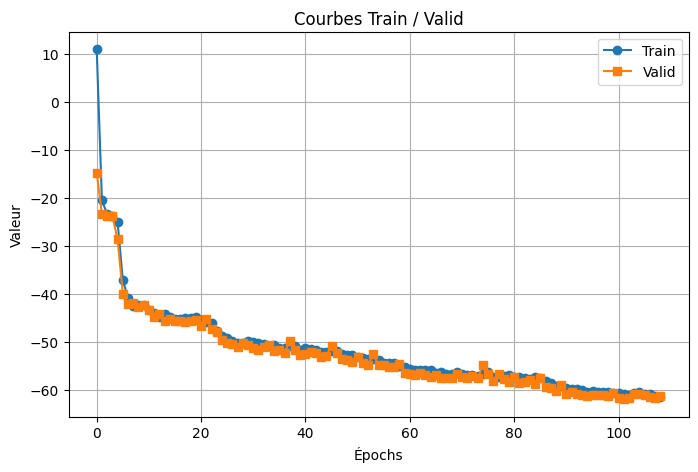

In [20]:
# Chemin vers le fichier JSON (ex: dossier "data")
chemin_fichier = os.path.join("checkpoints", "history.json")

def lire_json(chemin):
    try:
        with open(chemin, "r", encoding="utf-8") as fichier:
            contenu = json.load(fichier)
            return contenu
    except FileNotFoundError:
        print(f"Fichier introuvable : {chemin}")
    except json.JSONDecodeError:
        print("Erreur : le fichier n'est pas un JSON valide.")

# Lecture du contenu
data = lire_json(chemin_fichier)

if data:
    print("Contenu du JSON :")
    print(data)


train = data.get("train")
valid = data.get("val")

# Vérification
if train is None or valid is None:
    raise ValueError("Le fichier JSON doit contenir les clés 'train' et 'valid'")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train, label="Train", marker="o")
plt.plot(valid, label="Valid", marker="s")

plt.title("Courbes Train / Valid")
plt.xlabel("Épochs")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()

plt.show()


In [ ]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The function below is a modified version of the training function of the dataset, in which we added a scheduler for the learning rate, which reduces the learning rate when the validation curve becomes flat. 

In [32]:
#### modifications ajout scheduler learning rate
import os
import json
import torch
from tqdm import tqdm

def save_checkpoint(state, checkpoint_dir, name="last.pt"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, name)
    torch.save(state, path)

# MODIFICATION 1 : Ajout de l'argument 'scheduler' pour recharger son état
def load_checkpoint(model, optimizer, scheduler, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    
    # On charge l'état du scheduler s'il existe dans la sauvegarde
    if "scheduler_state" in checkpoint and scheduler is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Checkpoint loaded from: {checkpoint_path}")
    return start_epoch, history

def train_model_with_scheduler(
    model,
    train_loader,
    val_loader,
    checkpoint_dir="checkpoints",
    resume=False,
    epochs=50,
    batch_size=32,
    lr=1e-4,
    kl_anneal_epochs=10,
    patience=20, 
    device="cuda"
):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # MODIFICATION 2 : Initialisation du Scheduler
    # factor=0.5 : Divise le learning rate par 2 quand ça stagne
    # patience=5 : Attend 5 epochs de stagnation avant d'agir
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Tracking
    history = {
        "train": [], "val": [], "beta": [],
        "train_recon": [], "train_kld": [],
        "val_recon": [], "val_kld": [],
        "lr": [] # MODIFICATION : On garde une trace du Learning Rate
    }

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume training
    last_ckpt = os.path.join(checkpoint_dir, "last.pt")
    if resume and os.path.exists(last_ckpt):
        # MODIFICATION : On passe le scheduler à la fonction de chargement
        start_epoch, history = load_checkpoint(model, optimizer, scheduler, last_ckpt, device)
        print(f"Resuming from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_recon, total_kld = 0, 0
        n_batches = 0

        # Calcul de Beta (KL Annealing)
        beta = min(1.0, epoch / kl_anneal_epochs) if kl_anneal_epochs > 0 else 1.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            batch = batch.to(device)             
            batch = batch.permute(1, 0, 2)       
            seq_len, batch_size, _ = batch.shape

            optimizer.zero_grad()
            _,recon, kld = model(batch)

            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)
            loss = recon + beta * kld

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

        train_recon = total_recon / n_batches
        train_kld = total_kld / n_batches
        train_loss = train_recon + beta * train_kld

        # Validation
        val_recon, val_kld = evaluate(model, val_loader, device=device)
        val_loss = val_recon + beta * val_kld

        # MODIFICATION 3 : Step du Scheduler
        # On informe le scheduler de la nouvelle validation loss
        scheduler.step(val_loss)
        
        # Récupération du LR actuel pour l'affichage
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1}/{epochs}] "
              f"Train: {train_loss:.3f} | Val: {val_loss:.3f} | "
              f"β={beta:.3f} | LR={current_lr:.2e}")

        # Update history
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["beta"].append(beta)
        history["train_recon"].append(train_recon)
        history["train_kld"].append(train_kld)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        history["lr"].append(current_lr) # On loggue le LR

        # Save Checkpoint Dict (Helper)
        # MODIFICATION 4 : On ajoute l'état du scheduler dans la sauvegarde
        checkpoint_dict = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(), # <--- ICI
            "history": history
        }

        # Save last checkpoint
        save_checkpoint(checkpoint_dict, checkpoint_dir, "last.pt")

        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            save_checkpoint(checkpoint_dict, checkpoint_dir, "best.pt")
            patience_counter = 0
            print(" → Saved BEST model")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    # Save history as JSON
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        # Helper pour rendre les float32 sérialisables en JSON si besoin
        class FloatEncoder(json.JSONEncoder):
            def default(self, obj):
                if isinstance(obj, torch.Tensor): return obj.item()
                return json.JSONEncoder.default(self, obj)
        json.dump(history, f, indent=4, cls=FloatEncoder)

    print("\nTraining complete.")
    return history

Epoch 1/200 Training: 100%|██████████| 74/74 [00:10<00:00,  7.23it/s]


[1/200] Train: 0.450 | Val: -19.900 | β=0.000 | LR=1.00e-03
 → Saved BEST model


Epoch 2/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.37it/s]


[2/200] Train: -22.123 | Val: -24.206 | β=0.033 | LR=1.00e-03
 → Saved BEST model


Epoch 3/200 Training: 100%|██████████| 74/74 [00:11<00:00,  6.52it/s]


...

[198/200] Train: -66.964 | Val: -67.407 | β=1.000 | LR=1.25e-04


Epoch 199/200 Training: 100%|██████████| 74/74 [00:10<00:00,  7.30it/s]


[199/200] Train: -67.071 | Val: -67.390 | β=1.000 | LR=1.25e-04


Epoch 200/200 Training: 100%|██████████| 74/74 [00:09<00:00,  8.02it/s]


[200/200] Train: -67.183 | Val: -67.480 | β=1.000 | LR=1.25e-04
 → Saved BEST model

Training complete.


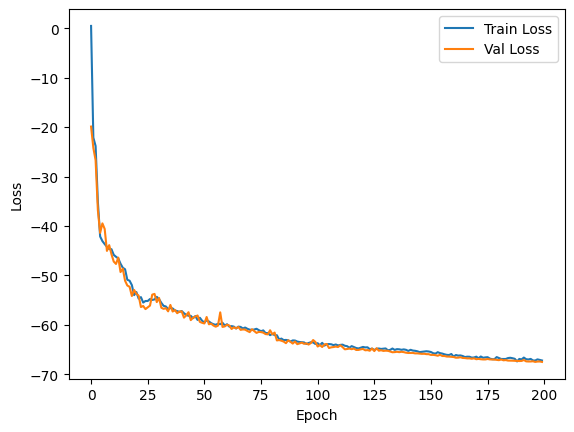

In [33]:
model_2 = VRNN().to(device)

history = train_model_with_scheduler(model=model_2, 
                                     train_loader=train_loader, 
                                     val_loader=val_loader,
                                     epochs=200,
                                     batch_size=32,
                                     lr=1e-3,
                                     kl_anneal_epochs=30, 
                                     patience=15,
                                     device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Contenu du JSON :
{'train': [0.44960996589145147, -22.12344355475795, -23.830126337962106, -35.11909459410487, -42.1159428106772, -43.05302534769247, -43.65202334893716, -44.20159386536022, -44.666380492201796, -44.69328661995965, -45.83267931250838, -46.22708998327857, -46.55049310632654, -47.62389199454505, -48.44411237218358, -48.739886087340274, -50.87241246335141, -51.06413770452276, -51.948678637839656, -53.97660756970311, -53.352816736375964, -54.689719581604, -54.37715790894654, -55.480123796119344, -55.16213467572186, -55.16319381009351, -54.76356501020827, -54.954309615573365, -54.84325830098745, -54.321012447546195, -54.781853650067305, -55.53518969303852, -56.14250585195181, -56.26871932519448, -56.80489168940364, -56.58810767611942, -56.66925020475646, -57.06844247354044, -57.203728882042135, -57.367596690719196, -57.19238019633938, -57.63219674857888, -57.97814614063984, -58.149784500534466, -58.163589361551644, -58.64223839785602, -58.211952273910114, -58.993012402508704

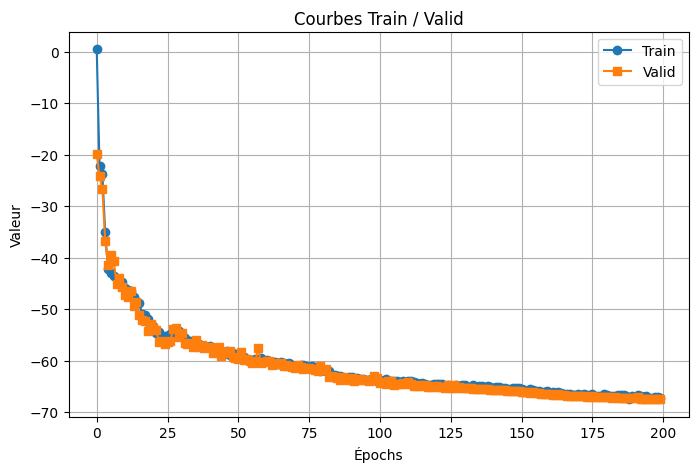

In [36]:
# Chemin vers le fichier JSON (ex: dossier "data")
chemin_fichier = os.path.join("checkpoints", "history.json")

def lire_json(chemin):
    try:
        with open(chemin, "r", encoding="utf-8") as fichier:
            contenu = json.load(fichier)
            return contenu
    except FileNotFoundError:
        print(f"Fichier introuvable : {chemin}")
    except json.JSONDecodeError:
        print("Erreur : le fichier n'est pas un JSON valide.")

# Lecture du contenu
data = lire_json(chemin_fichier)

if data:
    print("Contenu du JSON :")
    print(data)


train = data.get("train")
valid = data.get("val")

# Vérification
if train is None or valid is None:
    raise ValueError("Le fichier JSON doit contenir les clés 'train' et 'valid'")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train, label="Train", marker="o")
plt.plot(valid, label="Valid", marker="s")

plt.title("Courbes Train / Valid")
plt.xlabel("Épochs")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()

plt.show()


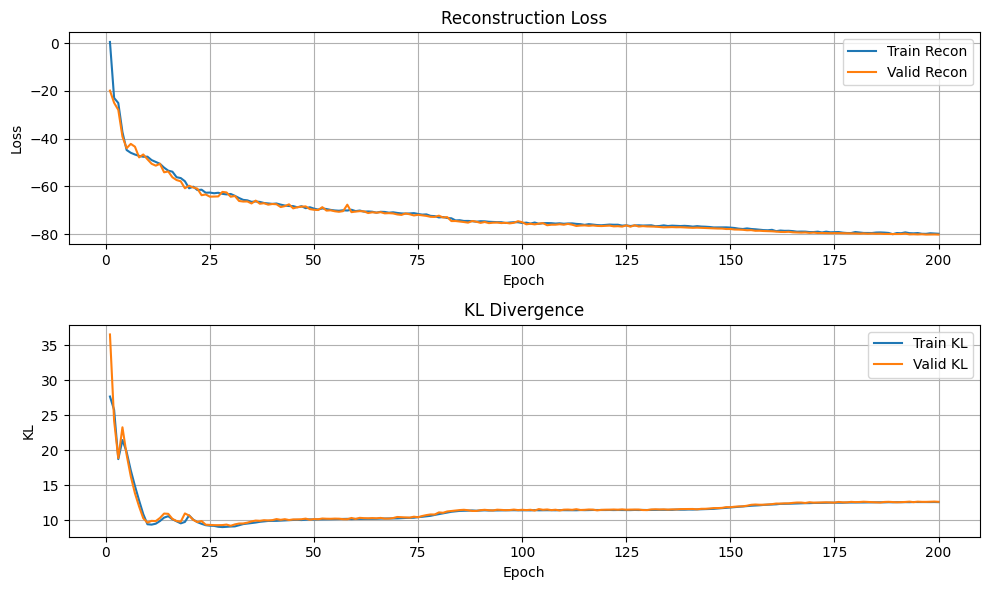

In [37]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Reconstruction of audios

In [12]:
!git checkout main

error: Your local changes to the following files would be overwritten by checkout:
	dataset/__pycache__/audio_dataset.cpython-313.pyc
	experiments/VRNN_project_notebook_colab.ipynb
	experiments/__pycache__/train.cpython-313.pyc
	model/__pycache__/VRNN.cpython-313.pyc
	utils/__pycache__/padding.cpython-313.pyc
Please commit your changes or stash them before you switch branches.
Aborting


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VRNN().to(device)

# 2. Définir le chemin vers le checkpoint
checkpoint_path = "checkpoints/best.pt"  

if not os.path.exists(checkpoint_path):
    print("Attention: 'best.pt' introuvable, essai avec 'last.pt'...")
    checkpoint_path = "checkpoints/last.pt"

# 3. Charger les poids
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    
    epoch_saved = checkpoint["epoch"]

    # Mettre en mode évaluation (bloque le Dropout, etc.)
    model.eval()
else:
    print("Aucun checkpoint trouvé.")

In [11]:
import librosa
import soundfile as sf
import IPython.display as ipd
import numpy as np

# --- CONFIGURATION ---
IDX_TO_TEST = 0  # Changez ce chiffre pour tester d'autres samples
STATS_PATH = "mel_stats.pt"

# 1. Charger les stats pour la dénormalisation
stats = torch.load(STATS_PATH)
# On gère le cas où stats serait sur GPU ou CPU
mean_val = stats["mean"].to('cpu')
std_val = stats["std"].to('cpu')


# 2. Récupérer l'input (Original)
# On prend un sample du dataset
data_item = full_dataset[IDX_TO_TEST]
original_mel = data_item

# 3. Passer dans le modèle (Reconstruction)
# Le modèle attend (Seq, Batch, Feat). Notre sample est (Seq, Feat).
# On ajoute la dimension batch avec unsqueeze(1)
input_tensor = original_mel.unsqueeze(1).to(device) # -> (200, 1, 80)

with torch.no_grad():
    recon_mel, _, _ = model(input_tensor) # Le modèle renvoie (recon, kld)

# On affiche la shape pour comprendre (optionnel, pour debug)
print(f"Shape sortie modèle : {recon_mel.shape}")

# Au lieu de forcer squeeze(1), on s'adapte :
# Si la shape est (200, 1, 80) -> squeeze(1) marche -> devient (200, 80)
# Si la shape est (200, 80)    -> Pas besoin de squeeze
# Si la shape est (1, 200, 80) -> squeeze(0) serait nécessaire

if recon_mel.dim() == 3 and recon_mel.shape[1] == 1:
    recon_mel = recon_mel.squeeze(1) # Cas attendu (Seq, 1, Feat) -> (Seq, Feat)
elif recon_mel.dim() == 3 and recon_mel.shape[0] == 1:
    recon_mel = recon_mel.squeeze(0) # Cas alternatif (1, Seq, Feat) -> (Seq, Feat)
original_mel = original_mel.cpu()

# 4. Fonction Helper : Mel -> Audio
def mel_to_audio_playable(mel_tensor, mean, std, name):

    # On force tout le monde sur le CPU pour éviter le crash
    mel_tensor = mel_tensor.detach().cpu()
    
    # A. Dénormalisation
    mel_denorm = mel_tensor * (std + 1e-6) + mean
    
    # B. Conversion Numpy & Transpose (Seq, Feat) -> (Feat, Seq)
    mel_numpy = mel_denorm.numpy().T
    
    # C. dB to Power
    mel_power = librosa.db_to_power(mel_numpy)
    
    # D. Griffin-Lim
    audio = librosa.feature.inverse.mel_to_audio(
        mel_power, sr=22050, n_fft=1024, hop_length=256, win_length=1024
    )
    
    # E. Sauvegarde et Affichage
    filename = f"{name}.wav"
    sf.write(filename, audio, 22050)
    print(f" {name} :")
    display(ipd.Audio(filename))

# 5. Lancer la comparaison
print(f"--- TEST SUR LE SAMPLE {IDX_TO_TEST} ---")
# Afficher le nom du fichier d'origine si possible
try:
    print(f"Fichier source : {get_real_filename(full_dataset, IDX_TO_TEST)}")
except:
    pass

mel_to_audio_playable(original_mel, mean_val, std_val, "1_Original_Input")
mel_to_audio_playable(recon_mel, mean_val, std_val, "2_Reconstructed_Output")

FileNotFoundError: [Errno 2] No such file or directory: 'mel_stats.pt'

## Reconstruction mel to wav

La classe utilisée initialement pour passer de wav à mel. Nécessaire pour réaccéder aux statistiques.

In [13]:
# import os
# import torch
# import soundfile as sf
# import torchaudio
# from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
# import torch.nn.functional as F
# import numpy as np

# # -----------------------
# # DATASET PYTORCH WAV SANS TORCHAUDIO.LOAD
# # -----------------------
# class MelDataset(torch.utils.data.Dataset):
#     def __init__(self, root, segment_frames=200, sample_rate=22050, n_mels=80):
#         self.root = root
#         self.segment_frames = segment_frames
#         self.sample_rate = sample_rate
        
#         self.mel = MelSpectrogram(
#             sample_rate=sample_rate,
#             n_fft=1024,
#             hop_length=256,
#             win_length=1024,
#             n_mels=n_mels
#         )
#         self.db = AmplitudeToDB()

#         # lister tous les fichiers wav
#         self.wav_files = []
#         for subfolder in os.listdir(root):
#             sub_path = os.path.join(root, subfolder)
#             if os.path.isdir(sub_path):
#                 for f in os.listdir(sub_path):
#                     if f.endswith(".wav"):
#                         self.wav_files.append(os.path.join(sub_path, f))

#         if len(self.wav_files) == 0:
#             raise RuntimeError("Aucun fichier .wav trouvé dans root.")

#         self._compute_statistics()

#     # -----------------------
#     # CHARGEMENT AUDIO AVEC SOUNDFILE
#     # -----------------------
#     def _load_wav(self, path):
#         wav, sr = sf.read(path)            # -> numpy array (N,) ou (N,2)
#         if wav.ndim == 2:                  # stereo → mono
#             wav = wav.mean(axis=1)
#         wav = wav.astype(np.float32)
        
#         # conversion tensor
#         wav = torch.tensor(wav).unsqueeze(0)  # (1,N)

#         # resample si nécessaire
#         if sr != self.sample_rate:
#             wav = torchaudio.functional.resample(wav, sr, self.sample_rate)

#         # normalisation amplitude
#         wav = wav / wav.abs().max()

#         return wav

#     # conversion en melspec
#     def _wav_to_mel(self, wav):
#         mel = self.mel(wav)
#         mel_db = self.db(mel)
#         return mel_db.squeeze(0).transpose(0, 1)  # (frames, mels)

#     # calcul mean/std global
#     def _compute_statistics(self):
#         print("Calcul des statistiques globales...")
#         mel_list = []
#         for path in self.wav_files:
#             wav = self._load_wav(path)
#             mel = self._wav_to_mel(wav)
#             mel_list.append(mel)

#         all_mels = torch.cat(mel_list, dim=0)
#         self.mean = all_mels.mean(dim=0)
#         self.std = all_mels.std(dim=0)
#         print("done.")

#     def __len__(self):
#         return len(self.wav_files)

#     def __getitem__(self, idx):
#         wav = self._load_wav(self.wav_files[idx])
#         mel = self._wav_to_mel(wav)

#         mel = (mel - self.mean) / (self.std + 1e-6)

#         if mel.shape[0] < self.segment_frames:
#             pad = self.segment_frames - mel.shape[0]
#             mel = F.pad(mel, (0, 0, 0, pad))

#         max_start = mel.shape[0] - self.segment_frames
#         start = torch.randint(0, max_start + 1, (1,)).item()
#         return mel[start:start + self.segment_frames]

In [14]:
# dataset = MelDataset(
#     root = "/home/onyxia/work/Dynamical-Variational-Autoencoders/data/data_wav",
#     segment_frames=200,
#     sample_rate=22050,
#     n_mels=80
# )

Calcul des statistiques globales...
done.


In [15]:
# print("Type des stats :", type(dataset.mean))
# print(f"Forme (Shape) : {dataset.mean.shape}") 

# print(f"Moyenne globale approx (dB) : {dataset.mean.mean().item():.2f}")
# print(f"Ecart-type global approx : {dataset.std.mean().item():.2f}")


# torch.save({
#     "mean": dataset.mean, 
#     "std": dataset.std
# }, "mel_stats.pt")

Type des stats : <class 'torch.Tensor'>
Forme (Shape) : torch.Size([80])
Moyenne globale approx (dB) : -16.93
Ecart-type global approx : 18.78


In [16]:
#fonction pour voir le 1er fichier qu'on a dans le dataset

def get_real_filename(dataset, target_idx):
    # 1. Cas : C'est un Subset (issu de random_split)
    if isinstance(dataset, torch.utils.data.Subset):
        real_idx = dataset.indices[target_idx]
        return get_real_filename(dataset.dataset, real_idx)

    # 2. Cas : C'est un ConcatDataset
    elif isinstance(dataset, torch.utils.data.ConcatDataset):
        current_idx = target_idx
        for sub_d in dataset.datasets:
            if current_idx < len(sub_d):
                return get_real_filename(sub_d, current_idx)
            current_idx -= len(sub_d)
            
    # 3. Cas final : C'est votre AudioDataset
    else:
        # On essaie plusieurs noms potentiels de variables
        potential_names = ['wav_files', 'files', 'paths', 'audio_files', 'data', 'file_paths']
        
        for name in potential_names:
            if hasattr(dataset, name):
                # On a trouvé le bon nom !
                return getattr(dataset, name)[target_idx]
        
        # Si on arrive ici, c'est qu'on n'a pas trouvé la variable
        print(f"ERREUR: Impossible de trouver la liste des fichiers dans {type(dataset)}")
        print(f"Les attributs disponibles sont : {list(dataset.__dict__.keys())}")
        return "Nom de variable introuvable"

# --- Test ---
filename = get_real_filename(full_dataset, 0)
print("Fichier audio correspondant :", filename)

Fichier audio correspondant : /home/onyxia/work/Dynamical-Variational-Autoencoders/data/mels_saved/part_0/mel_528.pt


In [17]:
import librosa
import soundfile as sf
import IPython.display as ipd

# On accède directement à l'index 0 du dataset
data_item = full_dataset[1]


if isinstance(data_item, tuple) or isinstance(data_item, list):
    mel_tensor = data_item[0] 
else:
    mel_tensor = data_item  

# ---------------------------------------------------------
# 2. CHARGER LES STATS
# ---------------------------------------------------------

stats = torch.load("mel_stats.pt")
mean_val = stats["mean"]
std_val = stats["std"]
print(mean_val,std_val)

# ---------------------------------------------------------
# 3. DÉNORMALISATION & CONVERSION
# ---------------------------------------------------------

# Dénormalisation
mel_denorm = mel_tensor * (std_val + 1e-6) + mean_val

# Passage en Numpy
mel_numpy = mel_denorm.detach().cpu().numpy()

# Librosa veut (Frequence, Temps).
if mel_numpy.shape[0] > mel_numpy.shape[1]: 
    mel_numpy = mel_numpy.T

# Inversion DB -> Power
mel_power = librosa.db_to_power(mel_numpy)

# ---------------------------------------------------------
# 4. RECONSTRUCTION (Griffin-Lim)
# ---------------------------------------------------------
audio_reconstruit = librosa.feature.inverse.mel_to_audio(
    mel_power,
    sr=22050,
    n_fft=1024,
    hop_length=256,
    win_length=1024
)

# ---------------------------------------------------------
# 5. ÉCOUTE
# ---------------------------------------------------------
sf.write('test_direct_0.wav', audio_reconstruit, 22050)
print(f"Vous écoutez le fichier : {get_real_filename(full_dataset, 1)}")
ipd.Audio('test_direct_0.wav')

tensor([  7.0757,   3.8944,   2.2081,   0.2902,  -1.5965,  -3.5759,  -2.0763,
         -4.5851,  -6.4180,  -8.2152,  -7.4840,  -6.6061,  -6.4498,  -6.9864,
         -7.3140,  -7.6709,  -8.8572, -10.8677, -12.8451, -13.8795, -14.4383,
        -14.9951, -15.0271, -15.0509, -15.0764, -15.4025, -15.6771, -16.1204,
        -16.6914, -16.8782, -16.8570, -16.9449, -16.7907, -17.0086, -17.0430,
        -17.1980, -17.1161, -17.2472, -17.5169, -18.0103, -18.2753, -18.4062,
        -18.4982, -18.6858, -18.8361, -18.8374, -18.6412, -18.5162, -18.5097,
        -18.5340, -18.7379, -19.0507, -19.5742, -20.3211, -20.8152, -21.2400,
        -21.9248, -22.5229, -23.1291, -23.9064, -24.7903, -25.5190, -26.1762,
        -26.5336, -26.7076, -26.6969, -26.5931, -26.5081, -26.1831, -26.0359,
        -26.2120, -26.0530, -25.6426, -25.7089, -26.1805, -26.7168, -26.8908,
        -27.1745, -27.6241, -28.1636]) tensor([ 6.4362,  7.0244,  9.8288, 13.7338, 16.6195, 20.0949, 22.9003, 23.1618,
        21.7860, 20.474

# Generation

In [ ]:
import librosa
import numpy as np

In [ ]:
import torch
import numpy as np
import torchaudio
from torchaudio.transforms import InverseMelScale
from IPython.display import Audio, display


@torch.no_grad()
def generate_and_listen_vrnn_mel(
    vrnn,
    ckpt_path,
    mean,
    std,
    seq_len,
    device="cpu",
    deterministic=False,
    sample_rate=22050,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=80,
    griffin_lim_iters=32
):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés
    """

    # ---------- Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model_state" in ckpt:
        vrnn.load_state_dict(ckpt["model_state"])
    else:
        vrnn.load_state_dict(ckpt)

    vrnn.to(device)
    vrnn.eval()

    # ---------- Safety checks
    assert vrnn.x_dim == n_mels, "x_dim ≠ n_mels"
    assert mean.shape[0] == n_mels
    assert std.shape[0] == n_mels

    # ---------- Generate normalized mel
    mel_norm = vrnn.generate(
        seq_len=seq_len,
        batch=1,
        device=device,
        deterministic=deterministic
    )

    mel_norm = mel_norm.squeeze(1).T  # (80, T)

    # ---------- De-normalize
    mean = mean.to(device).unsqueeze(1)
    std = std.to(device).unsqueeze(1)

    mel_db = mel_norm * std + mean

    # ---------- DB → amplitude
    mel = torch.pow(10.0, mel_db / 10.0)

    # ---------- Mel → STFT magnitude
    inv_mel = InverseMelScale(
        n_stft=n_fft // 2 + 1,
        n_mels=n_mels,
        sample_rate=sample_rate
    ).to(device)

    stft_mag = inv_mel(mel)

    # ---------- Griffin-Lim
    waveform = torchaudio.functional.griffinlim(
        stft_mag,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        power=1.0,
        n_iter=griffin_lim_iters
    )

    # ---------- Normalize
    waveform = waveform / (waveform.abs().max() + 1e-8)

    audio = waveform.squeeze().cpu().numpy()

    # ---------- Play
    display(Audio(audio, rate=sample_rate))

    return audio


In [ ]:
def generate_and_listen_vrnn_mel(vrnn, ckpt_path, mean, std, seq_len=400,
                                 deterministic=False, device="cpu",
                                 n_fft=1024, hop_length=256, win_length=1024,
                                 n_iter=32, sample_rate=22050):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés.
    Retourne un waveform torch.Tensor sur CPU.
    """
    # ----- Charger le checkpoint -----


    # ----- Génération du spectrogramme -----
    with torch.no_grad():
        mel = vrnn.generate(seq_len=seq_len, device=device, deterministic=deterministic).to(device)
        mel = mel * std + mean  # dénormalisation

    # ----- Inverse Mel → STFT -----
    inv_mel = torchaudio.transforms.InverseMelScale(
        n_stft=(n_fft // 2 + 1),
        n_mels=mel.shape[1],
        sample_rate=sample_rate
    )
    stft_mag = inv_mel(mel.T)  # shape: [freq, time]

    # ----- Redimension pour éviter le padding Griffin-Lim -----
    # expected_time = stft_mag.shape[1]
    # if expected_time < n_fft:
    #     stft_mag = F.pad(stft_mag, (0, n_fft - expected_time))

    # # # ----- Griffin-Lim -----
    # window = torch.hann_window(win_length).to(device)
    # waveform_length = stft_mag.shape[1] * hop_length

    # waveform = torchaudio.functional.griffinlim(
    #     specgram=stft_mag,
    #     n_fft=n_fft,
    #     hop_length=hop_length,
    #     win_length=win_length,
    #     window=window,
    #     power=1.0,
    #     n_iter=n_iter,
    #     momentum=0.99,
    #     length=waveform_length,
    #     rand_init=True
    # )

    # # ----- Normalisation finale -----
    # waveform = waveform / (waveform.abs().max() + 1e-8)

    # return waveform.cpu()

    return mel

In [ ]:

import torch.nn.functional as F

In [ ]:
vrnn = VRNN(
    x_dim=80,
    h_dim=256,
    z_dim=32,
    phi_x_dim=32,
    phi_z_dim=16
)

stats = torch.load("mel_stats.pt", map_location="cpu")

mean = stats["mean"]
std = stats["std"]

mel = generate_and_listen_vrnn_mel(
    vrnn=vrnn,
    ckpt_path="checkpoints/best.pt",
    mean=mean,
    std=std,
    seq_len=400,        # ≈ 400 frames
    deterministic=False,
    device="cpu"
)


FileNotFoundError: [Errno 2] No such file or directory: 'mel_stats.pt'

In [ ]:
import matplotlib.pyplot as plt

def plot_mel(mel, title="Mel spectrogram"):
    """
    mel: (T, 80) ou (80, T)
    """
    mel_2d = np.squeeze(mel)  # shape becomes (80, 400)

    plt.figure(figsize=(10, 4))
    plt.imshow(mel_2d, aspect="auto", origin="lower")
    plt.colorbar()
    plt.title("Mel Spectrogram")
    plt.show()


In [ ]:
plot_mel(mel)

NameError: name 'mel' is not defined

In [ ]:
def compare_stats(mel_real, mel_gen):
    print("REAL  mean:", mel_real.mean().item(), "std:", mel_real.std().item())
    print("GEN   mean:", mel_gen.mean().item(), "std:", mel_gen.std().item())


In [ ]:
def temporal_diff_energy(mel):
    diff = mel[1:] - mel[:-1]
    return diff.abs().mean().item()

print("REAL temporal diff:", temporal_diff_energy(mel_real))
print("GEN  temporal diff:", temporal_diff_energy(mel_gen))


NameError: name 'mel_real' is not defined